# KcBERT 특징 추출

- 정제된 리뷰 텍스트를 KcBERT 모델에 통과시켜 문장 임베딩 벡터를 추출한다.
- 추출된 768차원의 벡터는 이후 차원 축소 및 분류 모델(MLP 등)의 입력값으로 활용된다.
- KcBERT로 추출 시 전처리된 CSV 파일에서 clean_review_text만 추출한다.

### 라이브러리 로드

- 데이터 처리, 시각화 및 딥러닝 모델 활용을 위한 패키지를 임포트한다.
  1. pandas / numpy: 데이터프레임 및 행렬 연산
  2. matplotlib: 데이터 분포 시각화
  3. torch: PyTorch 텐서 연산 및 GPU 가속
  4. transformers: Hugging Face의 KcBERT 모델 및 토크나이저 불러오기
  5. tqdm: 배치 처리 진행률 파악

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
from tqdm.auto import tqdm

### GPU 환경 확인

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"현재 사용 중인 환경: {device}")

현재 사용 중인 환경: cuda


### 전처리된 데이터 로드

- 이전 단계(`data-process`)에서 정제한 리뷰 데이터(`preprocessed_reviews.csv`)를 불러온다.
- 전체 데이터 개수 및 리뷰 이벤트(label) 분포를 확인한다.
- 텍스트 길이와 레이블 분포를 시각화하여 데이터의 전반적인 특성을 파악한다.

전체 데이터 개수: 8841
label
0    5691
1    3150
Name: count, dtype: int64


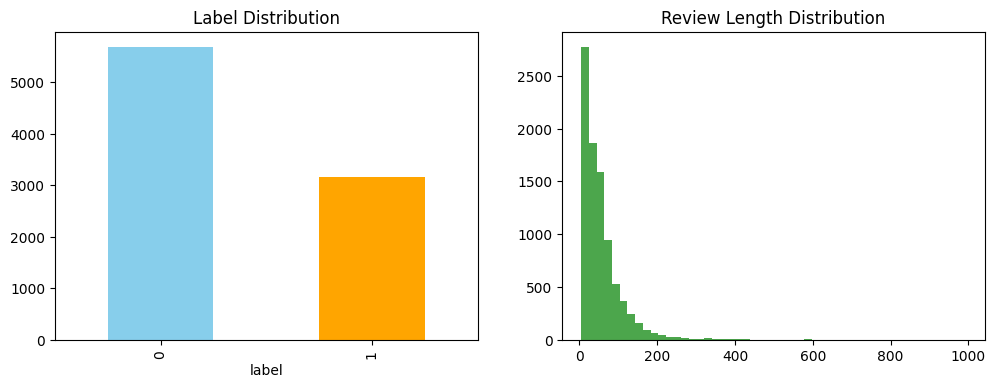

In [9]:
df = pd.read_csv('csv/preprocessed_reviews.csv')

print(f"전체 데이터 개수: {len(df)}")
print(df['label'].value_counts())

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

df['label'].value_counts().plot(kind='bar', ax=axs[0], color=['skyblue', 'orange'])
axs[0].set_title('Label Distribution')

# 리뷰 길이 분포 확인
axs[1].hist(df['text_length'], bins=50, color='green', alpha=0.7)
axs[1].set_title('Review Length Distribution')

plt.show()

### KcBERT 모델 로드 및 토크나이저 로드
- `beomi/kcbert-base` 사전 학습 모델과 토크나이저를 불러온다.
- 추가 학습(Fine-tuning)이 아닌 특징 추출(Feature Extraction)이 목적이므로 모델을 평가 모드(`model.eval()`)로 전환하여 가중치를 고정한다.

In [10]:
# 특징 추출기로 활용하기 위해 가중치를 고정
model_name = "beomi/kcbert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)

# 모델을 평가 모드로 전환 (특징 추출 모드)
model.eval()
print(f"{model_name} 로드 완료")

beomi/kcbert-base 로드 완료


### 배치 단위 임베딩 벡터 추출
- 메모리 부족(OOM) 방지를 위해 데이터를 지정된 배치 사이즈(batch_size)로 나누어 처리한다.
- `torch.no_grad()`를 통해 그래디언트 계산을 비활성화하여 추론 속도를 높인다.
- 문맥을 대표하는 `[CLS]` 토큰의 벡터(768차원)만 추출하여 리스트에 누적한 뒤, 최종적으로 병합(`np.vstack`)한다.
- 전처리 과정에서 정제된 cleaned_review_text만 KcBERT 특징 추출의 입력으로 사용한다.

In [11]:
input_series = df["cleaned_review_text"].fillna("").astype(str)
reviews = input_series.tolist()

print("전처리된 CSV 형태:", df.shape)
print("KcBERT 입력 컬럼 형태:", input_series.shape)
print("KcBERT 입력 컬럼명: cleaned_review_text")
print(input_series.head(3))

전처리된 CSV 형태: (8841, 15)
KcBERT 입력 컬럼 형태: (8841,)
KcBERT 입력 컬럼명: cleaned_review_text
0                 좋아하는집인데 배달은 안하시는게... 떡국이아니라 떡죽이네요...
1                                     ㄱㅇㄴㅅㄴㄷ이ㅣㄴㄷㄴㅇㄴㅇㄴㅈ
2    이걸 수습하기가 참.. 귀찮아서 국수로 간단히 끼니 해결하려 했는데 국물 다 흘러서...
Name: cleaned_review_text, dtype: object


### 실제 임베딩 추출

In [12]:
batch_size = 32
cls_embeddings = []

model.eval()

with torch.no_grad():
    for i in tqdm(range(0, len(reviews), batch_size)):
        batch_text = reviews[i : i + batch_size]

        inputs = tokenizer(
            batch_text,
            return_tensors="pt",
            truncation=True,
            max_length=128,
            padding="max_length"
        ).to(device)

        outputs = model(**inputs)

        # [CLS] 토큰 벡터 추출
        cls_vector = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        cls_embeddings.append(cls_vector)

# 배치별 결과를 하나로 합치기
final_embeddings = np.vstack(cls_embeddings)

100%|██████████| 277/277 [00:51<00:00,  5.41it/s]


In [13]:
print("전처리된 CSV 형태:", df.shape)
print("KcBERT 입력 리뷰 개수:", len(reviews))
print("KcBERT 입력 샘플 3개:")
for i, text in enumerate(reviews[:3]):
    print(f"{i}: {text}")

전처리된 CSV 형태: (8841, 15)
KcBERT 입력 리뷰 개수: 8841
KcBERT 입력 샘플 3개:
0: 좋아하는집인데 배달은 안하시는게... 떡국이아니라 떡죽이네요...
1: ㄱㅇㄴㅅㄴㄷ이ㅣㄴㄷㄴㅇㄴㅇㄴㅈ
2: 이걸 수습하기가 참.. 귀찮아서 국수로 간단히 끼니 해결하려 했는데 국물 다 흘러서모든 용기마다 닦아가며 정리하려니. 손대기도 싫고 입맛이 사라지네요 아..짜..


### 벡터 데이터 병합 및 최종 데이터 산출
- 추출된 768차원의 넘파이 배열을 `kcbert_0` ~ `kcbert_767` 형태의 개별 컬럼을 가진 데이터프레임으로 변환한다.
- 원본 메타데이터(별점, 사진 수 등)와 임베딩 벡터를 병합(`pd.concat`)한다.
- 최종 산출물을 `reviews_embeddings_extract.csv`로 저장한다.

In [14]:
# 768차원 배열을 각각의 컬럼으로 변환 
emb_columns = [f'kcbert_{i}' for i in range(final_embeddings.shape[1])]
df_embeddings = pd.DataFrame(final_embeddings, columns=emb_columns)

# 기존 메타데이터와 결합
df_final = pd.concat([df.reset_index(drop=True), df_embeddings], axis=1)

# CSV 저장 (인덱스 제외)
df_final.to_csv('csv/reviews_embeddings_extract.csv', index=False, encoding='utf-8-sig')
print("최종 산출물 저장 완료: reviews_embeddings_extract.csv")

최종 산출물 저장 완료: reviews_embeddings_extract.csv
